In [18]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets scikit-learn matplotlib seaborn

In [19]:
import torch, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

from peft import AdaLoraConfig, get_peft_model

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [20]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv(
    "/content/drive/MyDrive/Twitter Dataset (3 Classes).csv",
    encoding='ISO-8859-1'
)[['Text','Sentiment']].dropna()

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(
    df['Sentiment']
)

print("Label Mapping:")

for i,label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(

    df['Text'].tolist(),
    df['label'].tolist(),

    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts,test_texts,val_labels,test_labels = train_test_split(

    temp_texts,
    temp_labels,

    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(
f"\nTrain={len(train_texts)} | Val={len(val_texts)} | Test={len(test_texts)}"
)

Mounted at /content/drive
Label Mapping:
Negative: 0
Neutral: 1
Positive: 2

Train=49559 | Val=6195 | Test=6195


In [21]:
  tokenizer = AutoTokenizer.from_pretrained(
    "roberta-base"
)

train_enc = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_enc = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_enc = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)


class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self,encodings,labels):
        self.encodings=encodings
        self.labels=labels

    def __getitem__(self,idx):

        return {
            k:torch.tensor(v[idx])
            for k,v in self.encodings.items()
        } | {
            'labels':torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)


train_ds=SentimentDataset(
    train_enc,
    train_labels
)

val_ds=SentimentDataset(
    val_enc,
    val_labels
)

test_ds=SentimentDataset(
    test_enc,
    test_labels
)

In [22]:
def compute_metrics(eval_pred):

    logits,labels=eval_pred

    preds=np.argmax(
        logits,
        axis=1
    )

    acc=accuracy_score(
        labels,
        preds
    )*100

    prec,rec,f1,_=precision_recall_fscore_support(

        labels,
        preds,
        average='weighted'
    )

    return {

        "Accuracy":acc,
        "Precision":prec*100,
        "Recall":rec*100,
        "F1 Score":f1*100
    }

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(

    "roberta-base",
    num_labels=len(label_encoder.classes_)
)

adalora_cfg = AdaLoraConfig(

    init_r=12,
    target_r=4,

    beta1=0.85,
    beta2=0.85,

    tinit=200,
    tfinal=1000,
    deltaT=10,

    lora_alpha=32,
    lora_dropout=0.1,

    task_type="SEQ_CLS",

    target_modules=[
        "query",
        "value"
    ]
)

model = get_peft_model(
    model,
    adalora_cfg
)

args = TrainingArguments(

    output_dir="./adalora-roberta",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    fp16=True,

    save_total_limit=2,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",

    greater_is_better=False,

    report_to="none"
)

trainer = Trainer(

    model=model,
    args=args,

    train_dataset=train_ds,
    eval_dataset=val_ds,

    compute_metrics=compute_metrics
)

train_output=trainer.train()

metrics=trainer.evaluate(
    test_ds
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,0.710900,0.668989,72.800646,72.749551,72.800646,72.601523
2,0.665500,0.641075,73.559322,74.183220,73.559322,72.981069
3,0.646400,0.611286,75.189669,75.194120,75.189669,74.950921
4,0.610300,0.592915,76.158192,76.202002,76.158192,75.933011
5,0.612800,0.586322,76.497175,76.435984,76.497175,76.331687


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in ver

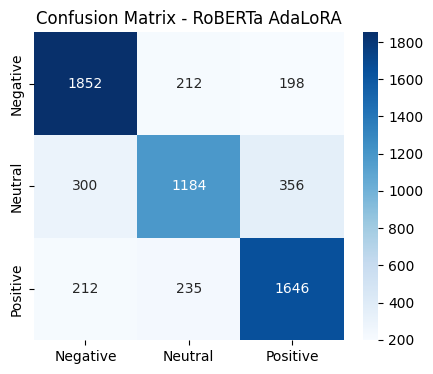

In [27]:
preds = np.argmax(preds_out.predictions,axis=1)

cm = confusion_matrix(
    test_ds.labels,
    preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix - RoBERTa AdaLoRA"
)

plt.show()

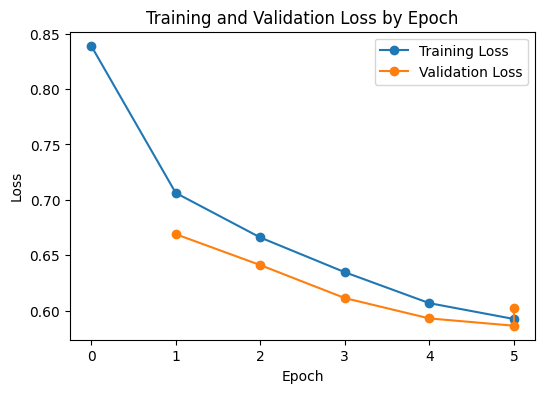

In [29]:
# Loss by Epoch

history = trainer.state.log_history

train_epochs = []
train_loss = []

eval_epochs = []
eval_loss = []

for x in history:

    if "eval_loss" in x:
        eval_epochs.append(x["epoch"])
        eval_loss.append(x["eval_loss"])

    if "loss" in x and "epoch" in x:
        train_epochs.append(x["epoch"])
        train_loss.append(x["loss"])

# Average training loss per epoch
epoch_train_loss = {}

for e, l in zip(train_epochs, train_loss):

    epoch = round(e)

    if epoch not in epoch_train_loss:
        epoch_train_loss[epoch] = []

    epoch_train_loss[epoch].append(l)

epoch_numbers = sorted(epoch_train_loss.keys())

avg_train_loss = [
    np.mean(epoch_train_loss[e])
    for e in epoch_numbers
]

plt.figure(figsize=(6,4))  # smaller size

plt.plot(
    epoch_numbers,
    avg_train_loss,
    marker='o',
    label='Training Loss'
)

plt.plot(
    eval_epochs,
    eval_loss,
    marker='o',
    label='Validation Loss'
)

plt.xticks(epoch_numbers)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss by Epoch"
)

plt.legend()

plt.show()

In [31]:
results = {

    "Model": "AdaLoRA RoBERTa",

    "Accuracy": f"{metrics['eval_Accuracy']:.2f}%",
    "Precision": f"{metrics['eval_Precision']:.2f}%",
    "Recall": f"{metrics['eval_Recall']:.2f}%",
    "F1 Score": f"{metrics['eval_F1 Score']:.2f}%",

    "Similarity": f"{similarity:.2f}%",
    "Confidence": f"{confidence:.2f}%",

    "Training Time (s)": f"{train_output.metrics['train_runtime']:.4f}",

    "Trainable Params": sum(
        p.numel() for p in model.parameters() if p.requires_grad
    ),

    "GPU Memory (GB)": f"{torch.cuda.max_memory_allocated() / 1024**3:.6f}"
}


df_results = pd.DataFrame([results])

print("\n==============================")
print("MODEL PERFORMANCE SUMMARY")
print("==============================")

print(df_results.to_string(index=False))


MODEL PERFORMANCE SUMMARY
          Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s)  Trainable Params GPU Memory (GB)
AdaLoRA RoBERTa   75.58%    75.44% 75.58%   75.41%     -7.32%     80.74%         2846.4794           1035555        1.091529
